In [14]:
!pip install open3d

Было точек: 121, стало ключевых точек: 11


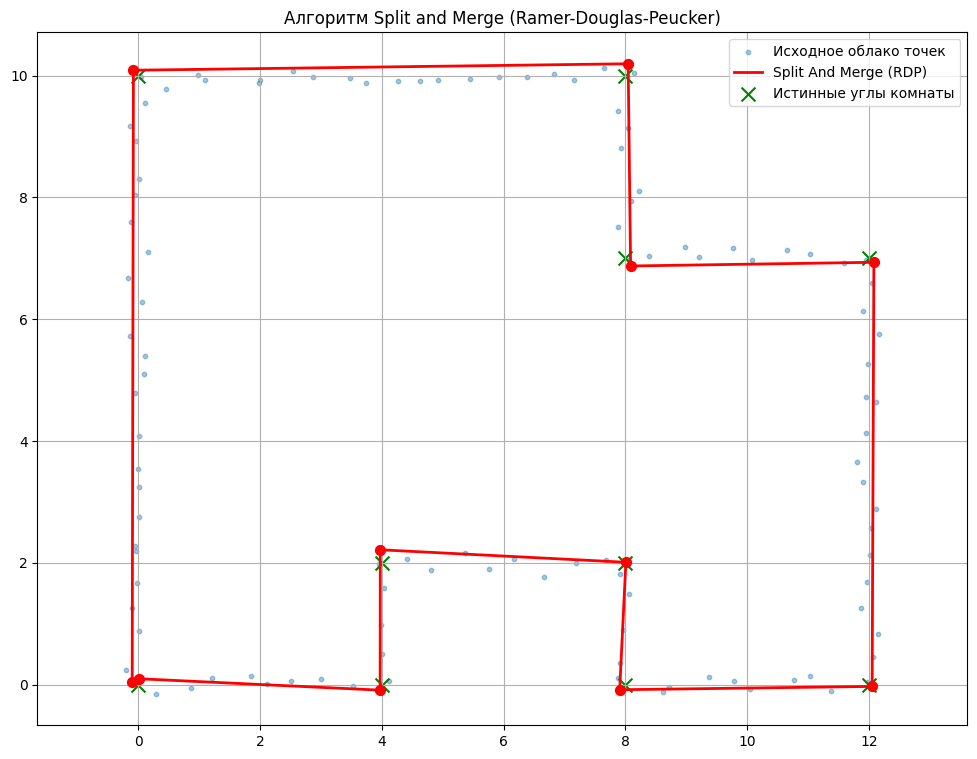

Найдено 0 линий.


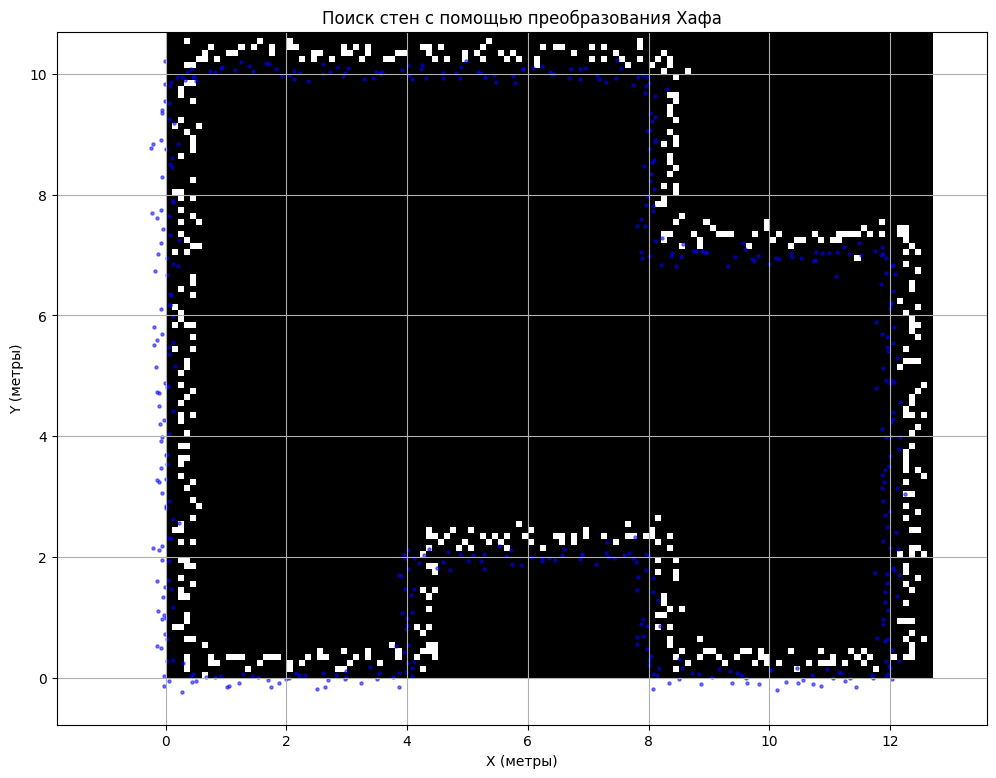

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import open3d as o3d
import copy
import random
from skimage.transform import hough_line, hough_line_peaks
from skimage.draw import line as draw_line


# =============================================================================
# Home Assignment 1.1: Wall Detection (2D LIDAR + Hough Transform)
# =============================================================================

def make_walls(vertex, body, step=0.4, scale=0.1):
    x_, y_ = [], []
    for i in range(vertex.shape[0]-1):
        x0, y0 = vertex[i]
        x1, y1 = vertex[i+1]
        r = np.linalg.norm(vertex[i] - vertex[i+1])
        n = np.round(r/step).astype(int)
        x_.append(np.linspace(x0, x1, n) + np.random.normal(loc=0, scale=scale, size=(n)))
        y_.append(np.linspace(y0, y1, n) + np.random.normal(loc=0, scale=scale, size=(n)))
    x0, y0 = vertex[-1]
    x1, y1 = vertex[0]
    r = np.linalg.norm(vertex[-1] - vertex[0])
    n = np.round(r/step).astype(int)
    x_.append(np.linspace(x0, x1, n) + np.random.normal(loc=0, scale=scale, size=(n)))
    y_.append(np.linspace(y0, y1, n) + np.random.normal(loc=0, scale=scale, size=(n)))
    x = np.concat(x_, axis=0)
    y = np.concat(y_, axis=0)
    walls = np.stack((x, y), axis=1)
    return walls

vertex = np.array([
    [0, 0], [0, 10], [8, 10], [8, 7], [12, 7], [12, 0], [8, 0], [8, 2], [4, 2], [4, 0]
])
body = np.array([5, 7])

walls = make_walls(vertex, body)

def distance_point_to_line(point, line_start, line_end):
    p = np.array(point)
    s = np.array(line_start)
    e = np.array(line_end)
    if np.array_equal(s, e):
        return np.linalg.norm(p - s)
    line_vec = e - s
    point_vec = p - s
    line_len = np.linalg.norm(line_vec)
    line_unit_vec = line_vec / line_len
    proj_length = np.dot(point_vec, line_unit_vec)
    if proj_length < 0:
        closest_point = s
    elif proj_length > line_len:
        closest_point = e
    else:
        closest_point = s + proj_length * line_unit_vec
    return np.linalg.norm(p - closest_point)

def split_and_merge(points, epsilon=0.5):
    if len(points) < 2:
        return list(range(len(points)))
    line_start = points[0]
    line_end = points[-1]
    max_dist = 0
    index = 0
    for i in range(1, len(points) - 1):
        dist = distance_point_to_line(points[i], line_start, line_end)
        if dist > max_dist:
            index = i
            max_dist = dist
    if max_dist < epsilon:
        return [0, len(points) - 1]
    else:
        left_indices = split_and_merge(points[:index+1], epsilon)
        right_indices = split_and_merge(points[index:], epsilon)
        combined_indices = left_indices[:-1] + [x + index for x in right_indices]
        return combined_indices

sparse_indices = split_and_merge(walls, epsilon=0.5)
sparse_walls = walls[sparse_indices]

print(f"Было точек: {len(walls)}, стало ключевых точек: {len(sparse_walls)}")

plt.figure(figsize=(12, 9))
plt.scatter(*walls.T, s=10, label='Исходное облако точек', alpha=0.4)
for i in range(len(sparse_walls) - 1):
    plt.plot(sparse_walls[i:i+2, 0], sparse_walls[i:i+2, 1], 'r-', linewidth=2)
plt.plot([sparse_walls[-1, 0], sparse_walls[0, 0]], [sparse_walls[-1, 1], sparse_walls[0, 1]], 'r-', linewidth=2, label='Split And Merge (RDP)')
plt.scatter(*sparse_walls.T, c='red', marker='o', s=50, zorder=5)
plt.scatter(*vertex.T, c='g', marker='x', s=100, label='Истинные углы комнаты')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.title("Алгоритм Split and Merge (Ramer-Douglas-Peucker)")
plt.show()

def points_to_image(points, pixel_size=0.1):
    min_coords = points.min(axis=0)
    max_coords = points.max(axis=0)
    x_range = max_coords[0] - min_coords[0]
    y_range = max_coords[1] - min_coords[1]
    buffer_units = pixel_size * 2
    img_width_units = x_range + buffer_units
    img_height_units = y_range + buffer_units
    img_width_pixels = int(np.ceil(img_width_units / pixel_size))
    img_height_pixels = int(np.ceil(img_height_units / pixel_size))
    image = np.zeros((img_height_pixels, img_width_pixels), dtype=np.uint8)
    offset_x = min_coords[0] - pixel_size
    offset_y = min_coords[1] - pixel_size
    pixel_x = ((points[:, 0] - offset_x) / pixel_size).astype(int)
    pixel_y = ((points[:, 1] - offset_y) / pixel_size).astype(int)
    pixel_x = np.clip(pixel_x, 0, img_width_pixels - 1)
    pixel_y = np.clip(pixel_y, 0, img_height_pixels - 1)
    image[pixel_y, pixel_x] = 255
    return image

step = 0.1
walls = make_walls(vertex, body, step=step)
pixel_size = 0.1
image_walls = points_to_image(walls, pixel_size=pixel_size)

tested_angles = np.linspace(-np.pi / 2, np.pi / 2, 360, endpoint=False)
h, theta, d = hough_line(image_walls, theta=tested_angles)

hspace, angles, dists = hough_line_peaks(h, theta, d, threshold=len(walls)*0.1)

print(f"Найдено {len(angles)} линий.")

plt.figure(figsize=(12, 9))
plt.imshow(image_walls, cmap='gray', origin='lower',
           extent=[0, image_walls.shape[1]*pixel_size, 0, image_walls.shape[0]*pixel_size])

for _, angle, dist in zip(hspace, angles, dists):
    y0 = (dist - 0 * np.cos(angle)) / np.sin(angle)
    y1 = (dist - image_walls.shape[1]*pixel_size * np.cos(angle)) / np.sin(angle)
    x0 = 0
    x1 = image_walls.shape[1]*pixel_size
    plt.plot([x0, x1], [y0, y1], '-r', linewidth=1)

plt.scatter(*walls.T, s=5, c='blue', alpha=0.5)
plt.title('Поиск стен с помощью преобразования Хафа')
plt.xlabel('X (метры)')
plt.ylabel('Y (метры)')
plt.grid(True)
plt.axis('equal')
plt.show()




In [16]:
# =============================================================================
# Home Assignment 1.2: Ground Detection (RANSAC) - Colab version
# =============================================================================

import open3d as o3d
import numpy as np
import random
import plotly.graph_objects as go

print("Загрузка примера данных из Open3D...")
point_cloud = o3d.data.PCDPointCloud()
pcd = o3d.io.read_point_cloud(point_cloud.path)
pcd = pcd.uniform_down_sample(10)
points = np.asarray(pcd.points)
print(f"Загружено {len(points)} точек.")

def ransac_plane(points, distance_threshold=0.03, max_trials=1000):
    best_inliers = []
    num_points = len(points)

    for _ in range(max_trials):
        idx = random.sample(range(num_points), 3)
        p1, p2, p3 = points[idx]

        v1 = p2 - p1
        v2 = p3 - p1
        normal = np.cross(v1, v2)
        if np.linalg.norm(normal) < 1e-6:
            continue
        normal = normal / np.linalg.norm(normal)
        d = -np.dot(normal, p1)

        distances = np.abs(np.dot(points, normal) + d)
        inliers = np.where(distances < distance_threshold)[0]

        if len(inliers) > len(best_inliers):
            best_inliers = inliers

    return best_inliers

# Ищем плоскость
inliers = ransac_plane(points)

print(f"Найдено инлайнеров: {len(inliers)} из {len(points)}")

# Разделяем точки
inlier_points = points[inliers]
outlier_mask = np.ones(len(points), dtype=bool)
outlier_mask[inliers] = False
outlier_points = points[outlier_mask]

# Визуализация через Plotly (работает в Colab)
fig = go.Figure()

# Добавляем инлайнеры (пол/стол) - зеленые
fig.add_trace(go.Scatter3d(
    x=inlier_points[:, 0], y=inlier_points[:, 1], z=inlier_points[:, 2],
    mode='markers',
    marker=dict(size=2, color='green'),
    name='Инлайнеры (пол/стол)'
))

# Добавляем аутлайнеры (препятствия) - красные
fig.add_trace(go.Scatter3d(
    x=outlier_points[:, 0], y=outlier_points[:, 1], z=outlier_points[:, 2],
    mode='markers',
    marker=dict(size=2, color='red'),
    name='Аутлайнеры (препятствия)'
))

fig.update_layout(
    title='RANSAC: Инлайнеры (зеленые) и Аутлайнеры (красные)',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    width=1000,
    height=800
)

fig.show()

# Демонстрация чувствительности к параметрам
print("--- Демонстрация с плохими параметрами (max_trials=10) ---")
for i in range(5):
    inliers_bad = ransac_plane(points, max_trials=10)
    print(f"Попытка {i+1}: Найдено инлайнеров: {len(inliers_bad)}")

inliers_good = ransac_plane(points, max_trials=1000)
print(f"Хороший параметр: Найдено инлайнеров: {len(inliers_good)}")

Загрузка примера данных из Open3D...
Загружено 11367 точек.
Найдено инлайнеров: 8793 из 11367


--- Демонстрация с плохими параметрами (max_trials=10) ---
Попытка 1: Найдено инлайнеров: 8614
Попытка 2: Найдено инлайнеров: 8638
Попытка 3: Найдено инлайнеров: 8868
Попытка 4: Найдено инлайнеров: 8561
Попытка 5: Найдено инлайнеров: 7292
Хороший параметр: Найдено инлайнеров: 8830
